## 1. Import thư viện cho EDA & Regression Modeling

In [61]:
import kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.impute import KNNImputer

In [4]:
path = kagglehub.dataset_download("nelgiriyewithana/global-weather-repository")
print("Path to dataset files:", path)

100%|██████████| 12.2M/12.2M [00:01<00:00, 6.59MB/s]

Extracting files...


Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\nelgiriyewithana\global-weather-repository\versions\1023


In [5]:
df = pd.read_csv(f"{path}/GlobalWeatherRepository.csv")

In [6]:
df

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.5200,69.1800,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.3300,19.8200,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.7600,3.0500,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.5000,1.5200,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.8400,13.2300,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154746,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,1784700000,2026-07-22 02:00,16.1,61.0,Clear,...,13.2,26.5,1,2,06:14 AM,06:53 PM,01:32 PM,12:34 AM,Waxing Gibbous,57
154747,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1784699100,2026-07-22 12:45,33.3,91.9,Moderate or heavy rain with thunder,...,84.1,86.8,4,10,05:26 AM,06:39 PM,12:52 PM,Does not set today,Waxing Gibbous,52
154748,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1784700000,2026-07-22 09:00,23.2,73.7,Sunny,...,30.2,85.2,2,3,05:42 AM,06:36 PM,12:59 PM,Does not set today,Waxing Gibbous,54
154749,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,1784699100,2026-07-22 07:45,14.7,58.5,Sunny,...,26.3,27.9,2,3,06:32 AM,05:53 PM,12:16 PM,12:37 AM,Waxing Gibbous,54


## 2. Khám phá & làm sạch dữ liệu

Kiểm tra kiểu dữ liệu, giá trị thiếu, và loại bỏ các cột trùng đơn vị / rò rỉ dữ liệu (leakage) so với target `temperature_celsius`.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 154751 entries, 0 to 154750
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       154751 non-null  str    
 1   location_name                 154751 non-null  str    
 2   latitude                      154751 non-null  float64
 3   longitude                     154751 non-null  float64
 4   timezone                      154751 non-null  str    
 5   last_updated_epoch            154751 non-null  int64  
 6   last_updated                  154751 non-null  str    
 7   temperature_celsius           154751 non-null  float64
 8   temperature_fahrenheit        154751 non-null  float64
 9   condition_text                154751 non-null  str    
 10  wind_mph                      154751 non-null  float64
 11  wind_kph                      154751 non-null  float64
 12  wind_degree                   154751 non-null  int64  


In [8]:
df.isna().sum()[df.isna().sum() > 0]   # xác nhận không có giá trị thiếu

Series([], dtype: int64)

In [9]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,154751.000000,154751.000000,1.547510e+05,154751.000000,154751.000000,154751.00000,154751.000000,154751.000000,154751.000000,154751.000000,...,154751.000000,154751.000000,154751.000000,154751.000000,154751.000000,154751.000000,154751.000000,154751.000000,154751.000000,154751.000000
mean,19.246657,21.874565,1.750291e+09,21.378071,70.482288,7.93175,12.768674,169.661062,1014.051845,29.944373,...,18.078555,432.547287,57.755731,14.350252,9.837904,23.259842,46.701225,1.665857,2.528449,49.821571
std,24.395955,65.776319,1.988343e+07,9.471369,17.048325,6.98179,11.232625,103.531593,9.928505,0.293132,...,13.491340,720.906365,30.757540,22.762774,33.685681,35.360682,143.758385,0.923591,2.392142,35.054761
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.20000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.733136e+09,16.100000,61.000000,3.80000,6.100000,81.000000,1010.000000,29.830000,...,10.000000,184.814000,38.000000,1.750000,1.100000,6.850000,9.650000,1.000000,1.000000,15.000000
50%,17.250000,21.433300,1.750324e+09,23.700000,74.700000,6.70000,10.800000,163.000000,1014.000000,29.930000,...,15.100000,276.850000,54.400000,5.550000,2.400000,13.505000,19.100000,1.000000,2.000000,50.000000
75%,40.400000,49.882200,1.767424e+09,27.900000,82.200000,10.70000,17.300000,256.000000,1018.000000,30.060000,...,24.000000,436.600000,73.000000,16.350000,7.770000,26.640000,39.950000,2.000000,3.000000,85.000000
max,65.300000,179.220000,1.784700e+09,79.300000,174.700000,1841.20000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [10]:
# Loại các cột trùng đơn vị (giữ 1 cột/đại lượng, giữ đơn vị celsius và km)
drop_cols = [
    'temperature_fahrenheit',        # trùng temperature_celsius (target)
    'feels_like_celsius', 'feels_like_fahrenheit',  # tính trực tiếp từ temperature -> leakage
    'wind_mph', 'gust_mph',          # trùng wind_kph / gust_kph
    'pressure_in',                   # trùng pressure_mb
    'visibility_miles',              # trùng visibility_km
]
df1 = df.drop(columns=drop_cols)

# Biến đổi last_updated thành int
df1['last_updated'] = pd.to_datetime(df1['last_updated'])
df1['month'] = df1['last_updated'].dt.month #tháng đi kèm với mùa có thể ảnh hưởng đến điều kiện thời tiết
df1['hour'] = df1['last_updated'].dt.hour #thời gian trong ngày có thể ảnh hưởng đến nhiệt độ
# năm, ngày không đủ ý nghĩa thống kê để đưa vào bài toán

df1[['last_updated', 'month', 'hour']]

,last_updated,month,hour
0,2024-05-16 13:15:00,5,13
1,2024-05-16 10:45:00,5,10
2,2024-05-16 09:45:00,5,9
3,2024-05-16 10:45:00,5,10
4,2024-05-16 09:45:00,5,9
...,...,...,...
154746,2026-07-22 02:00:00,7,2
154747,2026-07-22 12:45:00,7,12
154748,2026-07-22 09:00:00,7,9
154749,2026-07-22 07:45:00,7,7


## 2b. Chuẩn hoá tên quốc gia & lọc chỉ Châu Á

Cột `country` chứa nhiều biến thể trùng lặp do lỗi dịch/nhập liệu (vd `Inde`→India, `Südkorea`→South Korea,
`Kyrghyzstan`→Kyrgyzstan, `火鸡`/`Турция`→Turkey...)

In [11]:
df2 = df1.copy()

# Alias cho các biến thể tên quốc gia (đa ngôn ngữ / lỗi chính tả) xuất hiện trong dữ liệu
ASIA_ALIASES = {
    'Inde': 'India', 'Jemen': 'Yemen', 'Malásia': 'Malaysia', 'Südkorea': 'South Korea',
    'Turkménistan': 'Turkmenistan', 'Турция': 'Turkey', '火鸡': 'Turkey',
    'Saudi Arabien': 'Saudi Arabia', 'Kyrghyzstan': 'Kyrgyzstan',
}

# Danh sách quốc gia Châu Á (theo UN geoscheme, tên chuẩn tiếng Anh xuất hiện trong dữ liệu)
ASIA_COUNTRIES = {
    'Afghanistan', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Bhutan', 'Brunei Darussalam',
    'Cambodia', 'China', 'Cyprus', 'Georgia', 'India', 'Indonesia', 'Iran', 'Iraq', 'Israel', 'Japan',
    'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan', "Lao People's Democratic Republic", 'Lebanon',
    'Malaysia', 'Maldives', 'Mongolia', 'Myanmar', 'Nepal', 'North Korea', 'Oman', 'Pakistan',
    'Philippines', 'Qatar', 'Saudi Arabia', 'Singapore', 'South Korea', 'Sri Lanka', 'Syria',
    'Tajikistan', 'Thailand', 'Timor-Leste', 'Turkey', 'Turkmenistan', 'United Arab Emirates',
    'Uzbekistan', 'Vietnam', 'Yemen',
}

df2['country_clean'] = df2['country'].replace(ASIA_ALIASES)
df2 = df2[df2['country_clean'].isin(ASIA_COUNTRIES)].reset_index(drop=True)

print('Number of lines for Asia filter:', len(df2))
print('Number of countries:', df2['country_clean'].nunique())
df2[['country', 'country_clean', 'location_name']].head()

Number of lines for Asia filter: 40127
Number of countries: 47


,country,country_clean,location_name
0,Afghanistan,Afghanistan,Kabul
1,Armenia,Armenia,Yerevan
2,Azerbaijan,Azerbaijan,Baku
3,Bahrain,Bahrain,Manama
4,Bangladesh,Bangladesh,Dhaka


# PHẦN A — Dự đoán `temperature_celsius` (Regression, dữ liệu các quốc gia Châu Á)

## 3. Tương quan & chọn đặc trưng (feature selection)

Dùng hệ số Pearson để đánh giá mức độ liên hệ tuyến tính giữa từng biến số với `temperature_celsius`, loại các biến có |r| trong khoảng -0.3 đến 0.3 (tương quan yếu/không có).

In [13]:
df3 = df2.copy()

candidate_features = [
    'latitude', 'humidity', 'cloud', 'pressure_mb', 'wind_kph',
    'uv_index', 'precip_mm', 'visibility_km', 'month', 'hour',
]

corr_target = df3[candidate_features + ['temperature_celsius']].corr()['temperature_celsius'].drop('temperature_celsius')
corr_target.sort_values(key=abs, ascending=False)

uv_index         0.537020
pressure_mb     -0.427700
latitude        -0.420142
humidity        -0.267542
wind_kph         0.146852
visibility_km    0.131959
cloud           -0.128875
month            0.110958
hour             0.095259
precip_mm        0.032175
Name: temperature_celsius, dtype: float64

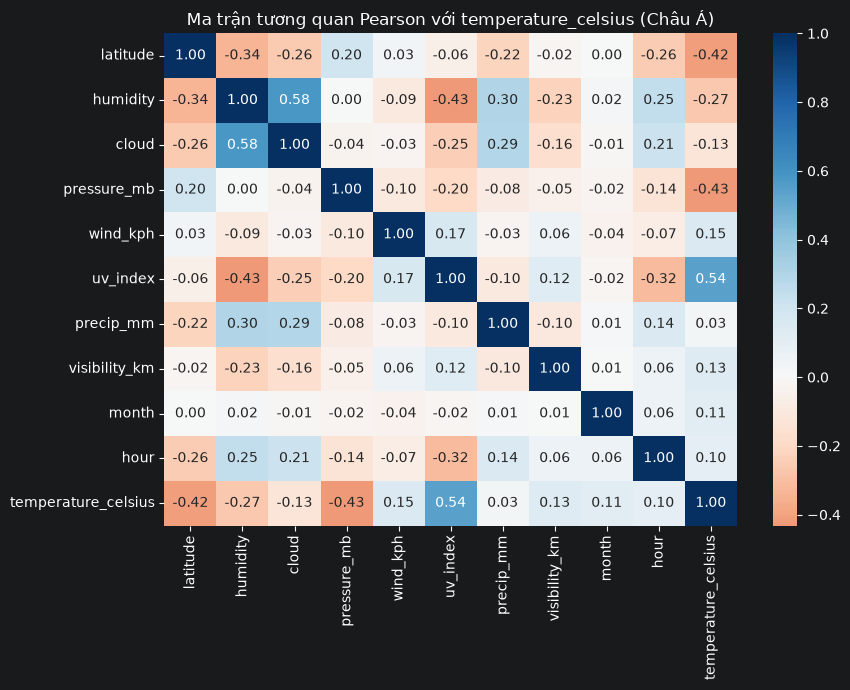

In [14]:
plt.figure(figsize=(9, 7))
sns.heatmap(df3[candidate_features + ['temperature_celsius']].corr(), annot=True, fmt='.2f', cmap='RdBu', center=0)
plt.title('Ma trận tương quan Pearson với temperature_celsius (Châu Á)')
plt.tight_layout()
plt.show()

In [35]:
# Chọn các đặc trưng có |r| > 0.3 với target làm tập feature cho mô hình
selected_features = corr_target[corr_target.abs() > 0.3].index.tolist()
print('Selected features:', selected_features)

x = df3[selected_features]
y = df3['temperature_celsius']

Selected features: ['latitude', 'pressure_mb', 'uv_index']


## 4. Simple Linear Regression (SLR) — baseline

Dùng đặc trưng có tương quan mạnh nhất làm baseline SLR, đánh giá bằng regression plot & residual plot.

In [36]:
df4 = df3.copy()

best_single_feature = corr_target.abs().idxmax()
print('Thr strongest related variable:', best_single_feature, '| r =', corr_target[best_single_feature])

slr = LinearRegression()
X_slr = df4[[best_single_feature]]
slr.fit(X_slr, y)
Yhat_slr = slr.predict(X_slr)

print('intercept:', slr.intercept_, '| coef:', slr.coef_)
print('R^2:', slr.score(X_slr, y))

Thr strongest related variable: uv_index | r = 0.5370202593194314
intercept: 16.85475918517423 | coef: [1.62773129]
R^2: 0.28839075891950283


In [37]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 40127 entries, 0 to 40126
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   country                       40127 non-null  str           
 1   location_name                 40127 non-null  str           
 2   latitude                      40127 non-null  float64       
 3   longitude                     40127 non-null  float64       
 4   timezone                      40127 non-null  str           
 5   last_updated_epoch            40127 non-null  int64         
 6   last_updated                  40127 non-null  datetime64[us]
 7   temperature_celsius           40127 non-null  float64       
 8   condition_text                40127 non-null  str           
 9   wind_kph                      40127 non-null  float64       
 10  wind_degree                   40127 non-null  int64         
 11  wind_direction                40127 non

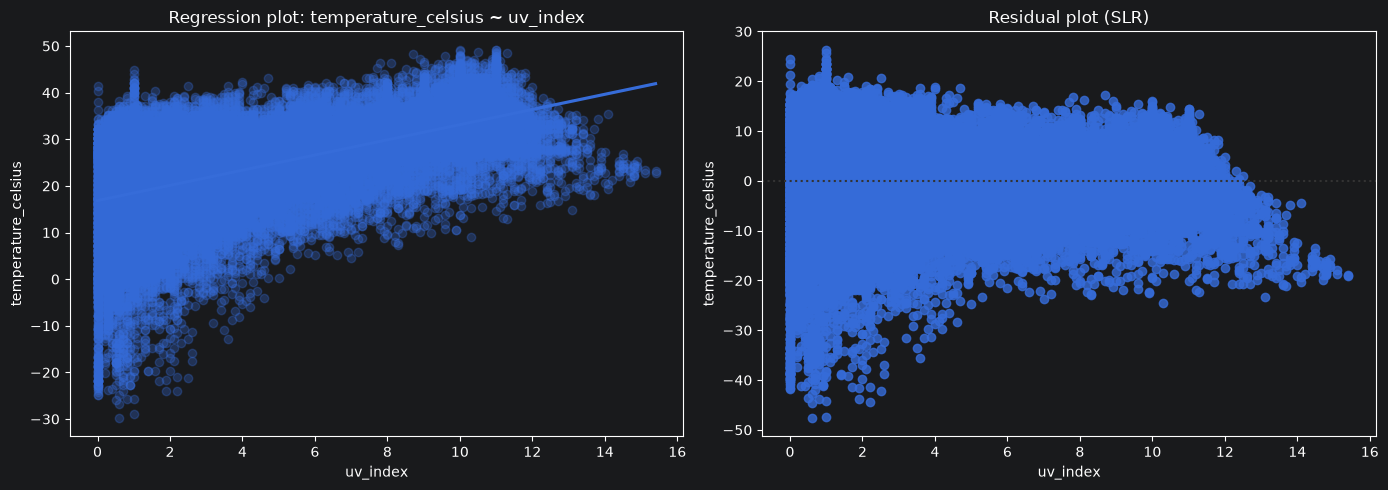

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(x=best_single_feature, y='temperature_celsius', data=df4, ax=axes[0], scatter_kws={'alpha': 0.3})
axes[0].set_title(f'Regression plot: temperature_celsius ~ {best_single_feature}')

sns.residplot(x=X_slr[best_single_feature], y=y, ax=axes[1])
axes[1].set_title('Residual plot (SLR)')
plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression (MLR) + Train/Test Split

Dùng toàn bộ `selected_features`, đánh giá trên tập test (không chỉ trên train) để tránh đánh giá sai do overfitting.

In [83]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=0)

In [84]:
mlr = LinearRegression()
mlr.fit(x_train, y_train)

yhat_train = mlr.predict(x_train)
yhat_test = mlr.predict(x_test)

results = {}
results['MLR'] = {
    'R2_train': mlr.score(x_train, y_train),
    'R2_test': mlr.score(x_test, y_test),
    'RMSE_test': mean_squared_error(y_test, yhat_test) ** 0.5,
}
print('MLR intercept:', mlr.intercept_)
print(pd.Series(mlr.coef_, index=selected_features).sort_values(key=abs, ascending=False))
results['MLR']

MLR intercept: 236.29207793386405
uv_index       1.415534
latitude      -0.246652
pressure_mb   -0.209485
dtype: float64


{'R2_train': 0.5010370484067168,
 'R2_test': 0.5487651372507873,
 'RMSE_test': 7.1297312708186285}

In [85]:
cv_scores = cross_val_score(mlr, x, y, cv=5)
cv_scores

array([ 0.07283214, -1.35642025, -0.03043339,  0.49654017,  0.40979462])

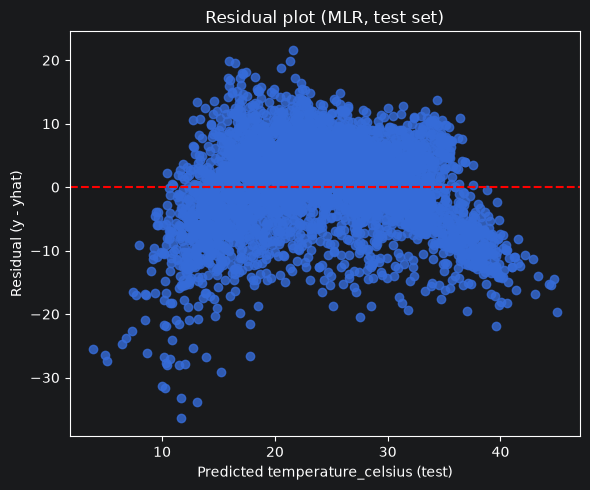

In [86]:
plt.figure(figsize=(6, 5))
sns.residplot(x=yhat_test, y=y_test - yhat_test)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted temperature_celsius (test)')
plt.ylabel('Residual (y - yhat)')
plt.title('Residual plot (MLR, test set)')
plt.tight_layout()
plt.show()

## 6. Polynomial Regression

Tăng dần bậc thức

In [89]:
for i in range(1,10):
    poly_pipe = Pipeline([
        ('scale', StandardScaler()),
        ('polynomial', PolynomialFeatures(degree=i, include_bias=False)),
        ('model', LinearRegression()),
    ])
    poly_pipe.fit(x_train, y_train)
    yhat_test_poly = poly_pipe.predict(x_test)
    results['Polynomial'] = {
        'R2_train': poly_pipe.score(x_train, y_train),
        'R2_test': poly_pipe.score(x_test, y_test),
        'RMSE_test': mean_squared_error(y_test, yhat_test_poly) ** 0.5,
    }
    print('degree', i,'has:', results['Polynomial'])

degree 1 has: {'R2_train': 0.5010370484067168, 'R2_test': 0.5487651372507878, 'RMSE_test': 7.129731270818626}
degree 2 has: {'R2_train': 0.7226380665892038, 'R2_test': 0.7409865030248464, 'RMSE_test': 5.401732027258799}
degree 3 has: {'R2_train': 0.7375480198735294, 'R2_test': 0.7559591530609681, 'RMSE_test': 5.243280595137649}
degree 4 has: {'R2_train': 0.7440811635181748, 'R2_test': 0.7614793780155344, 'RMSE_test': 5.183639666155015}
degree 5 has: {'R2_train': 0.7507604805697898, 'R2_test': 0.7673800944039397, 'RMSE_test': 5.119119590906487}
degree 6 has: {'R2_train': 0.6674631745982798, 'R2_test': 0.6600229680664068, 'RMSE_test': 6.18866004857078}
degree 7 has: {'R2_train': 0.00945586068747617, 'R2_test': 0.011587243872676956, 'RMSE_test': 10.552151278160624}
degree 8 has: {'R2_train': 0.0001263231197695669, 'R2_test': -0.00016158282634792798, 'RMSE_test': 10.61468039826437}
degree 9 has: {'R2_train': 0.00012632311976934485, 'R2_test': -0.00016158282634837207, 'RMSE_test': 10.614680

Lựa chọn bậc 4 là bậc tối ưu

In [103]:
poly_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=4, include_bias=False)),
    ('model', LinearRegression()),
])
poly_pipe.fit(x_train, y_train)
yhat_test_poly = poly_pipe.predict(x_test)
results['Polynomial_best_temperature'] = {
    'R2_train': poly_pipe.score(x_train, y_train),
    'R2_test': poly_pipe.score(x_test, y_test),
    'RMSE_test': mean_squared_error(y_test, yhat_test_poly) ** 0.5,
}
results['Polynomial_best_temperature']

{'R2_train': 0.7440811635181748,
 'R2_test': 0.7614793780155344,
 'RMSE_test': 5.183639666155015}

## 7. Ridge Regression (Regularization)

Các đặc trưng khí tượng (áp suất, độ ẩm, mây, gió) có thể đa cộng tuyến — dùng Ridge + `GridSearchCV` để tìm alpha tối ưu, kiểm tra Ridge có cải thiện so với Linear/Polynomial thường không.

In [90]:
ridge_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', Ridge()),
])

param_grid = {'model__alpha': np.logspace(-3, 4, 60)}
grid = GridSearchCV(ridge_pipe, param_grid, cv=4, scoring='r2')
grid.fit(x_train, y_train)

best_ridge = grid.best_estimator_
yhat_test_ridge = best_ridge.predict(x_test)

results['Ridge (best alpha)'] = {
    'R2_train': best_ridge.score(x_train, y_train),
    'R2_test': best_ridge.score(x_test, y_test),
    'RMSE_test': mean_squared_error(y_test, yhat_test_ridge) ** 0.5,
}
print('Best alpha:', grid.best_params_['model__alpha'])
results['Ridge (best alpha)']

Best alpha: 0.001


{'R2_train': 0.7226380665892016,
 'R2_test': 0.7409865027401685,
 'RMSE_test': 5.401732030227279}

## 8. So sánh mô hình

Bảng tổng hợp R²(train/test) và RMSE(test) của các mô hình đã thử — mô hình tốt là mô hình có R² test cao **và** không chênh lệch quá nhiều so với R² train (tránh overfitting).

In [91]:
results['SLR'] = {
    'R2_train': slr.score(X_slr, y),
    'R2_test': np.nan,  # SLR ở trên fit trên toàn bộ dữ liệu để minh hoạ baseline, không qua train/test split
    'RMSE_test': np.nan,
}

results_df = pd.DataFrame(results).T[['R2_train', 'R2_test', 'RMSE_test']]
results_df.sort_values('R2_test', ascending=False)

,R2_train,R2_test,RMSE_test
Ridge (best alpha),0.722638,0.740987,5.401732
MLR,0.501037,0.548765,7.129731
Polynomial,0.000126,-0.000162,10.614680
SLR,0.288391,NaN,NaN


# PHẦN B — Dự đoán `humidity` (chỉ số thời tiết dạng số, Regression, chỉ dữ liệu Châu Á)

Áp dụng lại đúng quy trình của Phần A (tương quan → SLR → MLR → Polynomial → Ridge) nhưng đổi target sang `humidity` (độ ẩm, %).
`precip_mm` không được chọn làm target vì ~67% giá trị bằng 0 (zero-inflated) — không phù hợp cho hồi quy tuyến tính thông thường.

## Tương quan & chọn đặc trưng cho `humidity`

In [93]:
df5 = df4.copy()
candidate_features_b = [
    'latitude', 'temperature_celsius', 'cloud', 'pressure_mb', 'wind_kph',
    'uv_index', 'precip_mm', 'visibility_km', 'month', 'hour',
]

corr_target_b = df5[candidate_features_b + ['humidity']].corr()['humidity'].drop('humidity')
corr_target_b.sort_values(key=abs, ascending=False)

cloud                  0.580773
uv_index              -0.431851
latitude              -0.337627
precip_mm              0.301325
temperature_celsius   -0.267542
hour                   0.248850
visibility_km         -0.225816
wind_kph              -0.091373
month                  0.017708
pressure_mb            0.004860
Name: humidity, dtype: float64

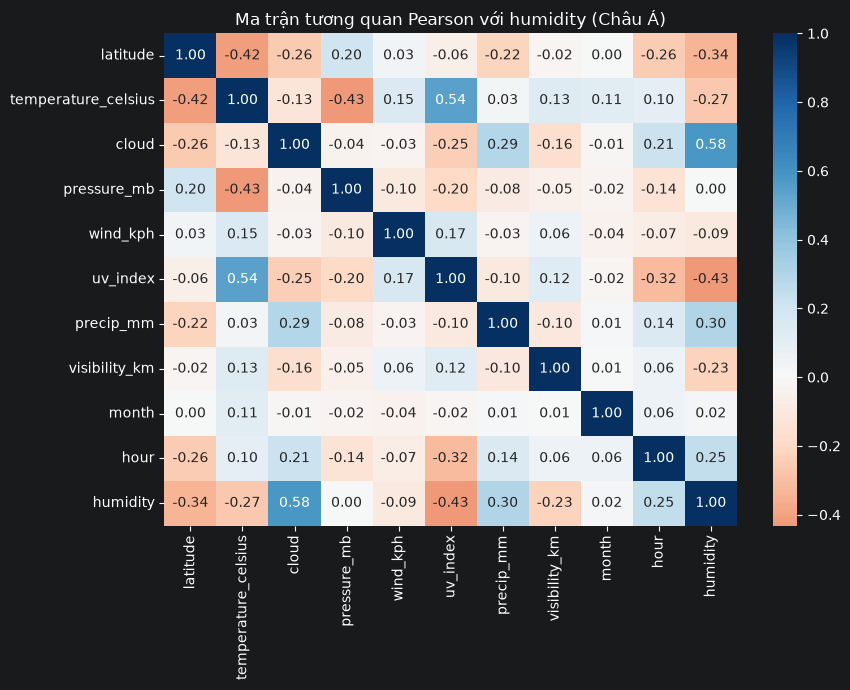

In [94]:
plt.figure(figsize=(9, 7))
sns.heatmap(df5[candidate_features_b + ['humidity']].corr(), annot=True, fmt='.2f', cmap='RdBu', center=0)
plt.title('Ma trận tương quan Pearson với humidity (Châu Á)')
plt.tight_layout()
plt.show()

In [95]:
selected_features_b = corr_target_b[corr_target_b.abs() > 0.3].index.tolist()
print('Selected features:', selected_features_b)

X_b = df5[selected_features_b]
y_b = df5['humidity']

Selected features: ['latitude', 'cloud', 'uv_index', 'precip_mm']


## SLR baseline cho `humidity`

In [97]:
best_single_feature_b = corr_target_b.abs().idxmax()
print('The strongest related variable:', best_single_feature_b, '| r =', corr_target_b[best_single_feature_b])

slr_b = LinearRegression()
X_slr_b = df5[[best_single_feature_b]]
slr_b.fit(X_slr_b, y_b)

print('intercept:', slr_b.intercept_, '| coef:', slr_b.coef_)
print('R^2', slr_b.score(X_slr_b, y_b))

The strongest related variable: cloud | r = 0.5807733618705503
intercept: 38.21255370371366 | coef: [0.41731173]
R^2 0.3372976978584151


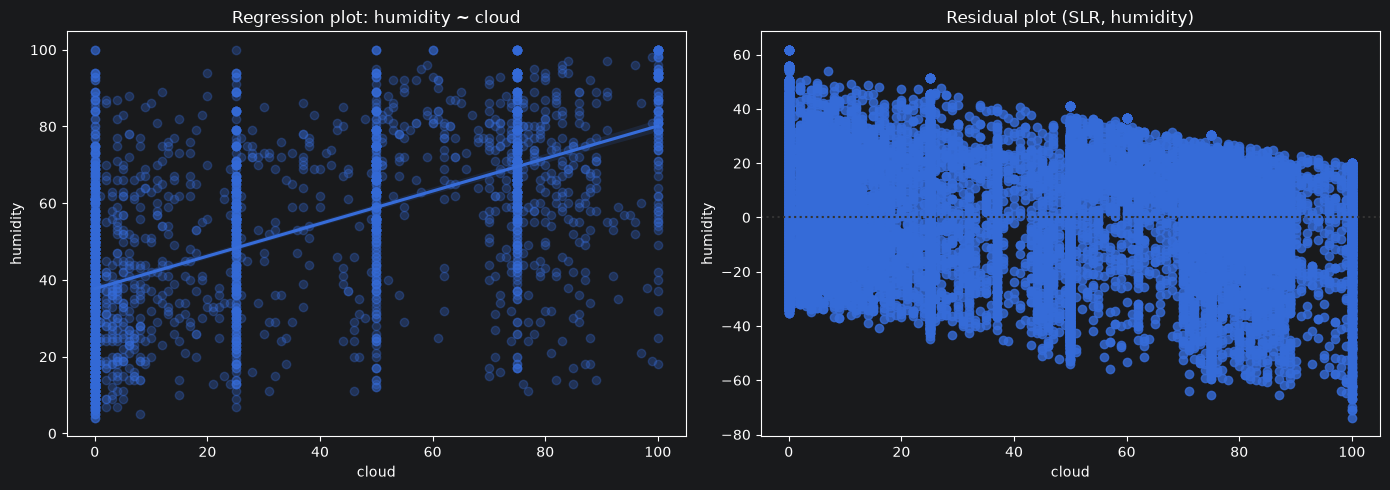

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample_b = df5.sample(3000, random_state=0)
sns.regplot(x=best_single_feature_b, y='humidity', data=sample_b, ax=axes[0], scatter_kws={'alpha': 0.3})
axes[0].set_title(f'Regression plot: humidity ~ {best_single_feature_b}')

sns.residplot(x=X_slr_b[best_single_feature_b], y=y_b, ax=axes[1])
axes[1].set_title('Residual plot (SLR, humidity)')
plt.tight_layout()
plt.show()

## MLR + Train/Test Split cho `humidity`

In [99]:
x_train_b, x_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.1, random_state=0)

In [100]:
mlr_b = LinearRegression()
mlr_b.fit(x_train_b, y_train_b)

yhat_test_b = mlr_b.predict(x_test_b)

results_b = {}
results_b['MLR'] = {
    'R2_train': mlr_b.score(x_train_b, y_train_b),
    'R2_test': mlr_b.score(x_test_b, y_test_b),
    'RMSE_test': mean_squared_error(y_test_b, yhat_test_b) ** 0.5,
}
print('MLR intercept:', mlr_b.intercept_)
print(pd.Series(mlr_b.coef_, index=selected_features_b).sort_values(key=abs, ascending=False))
results_b['MLR']

MLR intercept: 62.34917159739899
precip_mm    4.101721
uv_index    -2.331171
latitude    -0.374550
cloud        0.295686
dtype: float64


{'R2_train': 0.4884812619076633,
 'R2_test': 0.49804970136714055,
 'RMSE_test': 17.151442748984692}

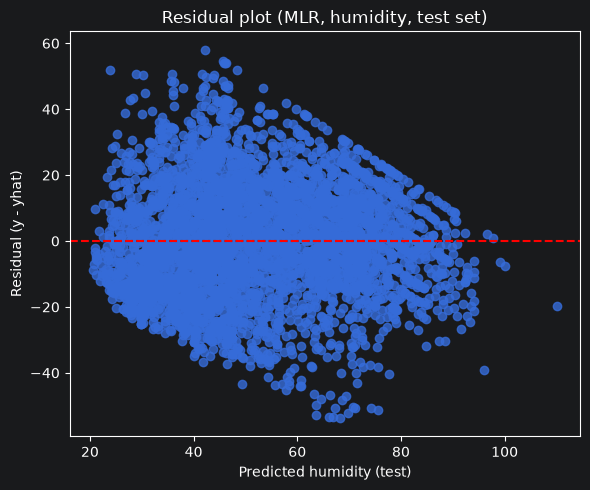

In [101]:
plt.figure(figsize=(6, 5))
sns.residplot(x=yhat_test_b, y=y_test_b - yhat_test_b)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted humidity (test)')
plt.ylabel('Residual (y - yhat)')
plt.title('Residual plot (MLR, humidity, test set)')
plt.tight_layout()
plt.show()

## Polynomial Regression cho `humidity`

In [102]:
for i in range(1,10):
    poly_pipe_humidity = Pipeline([
        ('scale', StandardScaler()),
        ('polynomial', PolynomialFeatures(degree=i, include_bias=False)),
        ('model', LinearRegression()),
    ])
    poly_pipe_humidity.fit(x_train, y_train)
    yhat_test_poly_humidity = poly_pipe_humidity.predict(x_test)
    results['Polynomial_humidity'] = {
        'R2_train': poly_pipe_humidity.score(x_train, y_train),
        'R2_test': poly_pipe_humidity.score(x_test, y_test),
        'RMSE_test': mean_squared_error(y_test, yhat_test_poly_humidity) ** 0.5,
    }
    print('degree', i,'has:', results['Polynomial_humidity'])

degree 1 has: {'R2_train': 0.5010370484067168, 'R2_test': 0.5487651372507878, 'RMSE_test': 7.129731270818626}
degree 2 has: {'R2_train': 0.7226380665892038, 'R2_test': 0.7409865030248464, 'RMSE_test': 5.401732027258799}
degree 3 has: {'R2_train': 0.7375480198735294, 'R2_test': 0.7559591530609681, 'RMSE_test': 5.243280595137649}
degree 4 has: {'R2_train': 0.7440811635181748, 'R2_test': 0.7614793780155344, 'RMSE_test': 5.183639666155015}
degree 5 has: {'R2_train': 0.7507604805697898, 'R2_test': 0.7673800944039397, 'RMSE_test': 5.119119590906487}
degree 6 has: {'R2_train': 0.6674631745982798, 'R2_test': 0.6600229680664068, 'RMSE_test': 6.18866004857078}
degree 7 has: {'R2_train': 0.00945586068747617, 'R2_test': 0.011587243872676956, 'RMSE_test': 10.552151278160624}
degree 8 has: {'R2_train': 0.0001263231197695669, 'R2_test': -0.00016158282634792798, 'RMSE_test': 10.61468039826437}
degree 9 has: {'R2_train': 0.00012632311976934485, 'R2_test': -0.00016158282634837207, 'RMSE_test': 10.614680

Lựa chọn bậc 5 là bậc tối ưu

In [105]:
poly_pipe_humidity = Pipeline([
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=5, include_bias=False)),
    ('model', LinearRegression()),
])
poly_pipe_humidity.fit(x_train, y_train)
yhat_test_poly_humidity = poly_pipe_humidity.predict(x_test)
results['Polynomial_best_humidity'] = {
    'R2_train': poly_pipe_humidity.score(x_train, y_train),
    'R2_test': poly_pipe_humidity.score(x_test, y_test),
    'RMSE_test': mean_squared_error(y_test, yhat_test_poly_humidity) ** 0.5,
}
results['Polynomial_best_humidity']

{'R2_train': 0.7507604805697898,
 'R2_test': 0.7673800944039397,
 'RMSE_test': 5.119119590906487}

## Ridge Regression cho `humidity`

In [ ]:
ridge_pipe_b = Pipeline([
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', Ridge()),
])

param_grid_b = {'model__alpha': np.logspace(-3, 4, 60)}
grid_b = GridSearchCV(ridge_pipe_b, param_grid_b, cv=4, scoring='r2')
grid_b.fit(x_train_b, y_train_b)

best_ridge_b = grid_b.best_estimator_
yhat_test_ridge_b = best_ridge_b.predict(x_test_b)

results_b['Ridge (best alpha)'] = {
    'R2_train': best_ridge_b.score(x_train_b, y_train_b),
    'R2_test': best_ridge_b.score(x_test_b, y_test_b),
    'RMSE_test': mean_squared_error(y_test_b, yhat_test_ridge_b) ** 0.5,
}
print('Best alpha:', grid_b.best_params_['model__alpha'])
results_b['Ridge (best alpha)']

## So sánh mô hình cho `humidity`

In [30]:
results_b['SLR'] = {
    'R2_train': slr_b.score(X_slr_b, y_b),
    'R2_test': np.nan,
    'RMSE_test': np.nan,
}

results_df_b = pd.DataFrame(results_b).T[['R2_train', 'R2_test', 'RMSE_test']]
results_df_b.sort_values('R2_test', ascending=False)

,R2_train,R2_test,RMSE_test
Ridge (best alpha),0.522504,0.520909,16.614446
Polynomial (deg=2),0.522527,0.520908,16.614458
MLR,0.488889,0.491504,17.116722
SLR,0.337259,NaN,NaN
